In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import gseapy as gp
import os
import pickle

import subcluster_funcs as funcs
sc._settings.settings._vector_friendly=True

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
post_subclustering_dir = "../post_subcluster_annotation/"
os.makedirs(post_subclustering_dir, exist_ok=True)
plots_dir = "plots_dir/"
os.makedirs(plots_dir, exist_ok=True)

In [3]:
cell_type = "Pericyte"

In [4]:
%%time
adata = sc.read_h5ad("../continuous_cov_corrected_no_scvi/" + cell_type  + ".h5ad")

CPU times: user 2.2 s, sys: 20.3 s, total: 22.6 s
Wall time: 26.7 s


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>

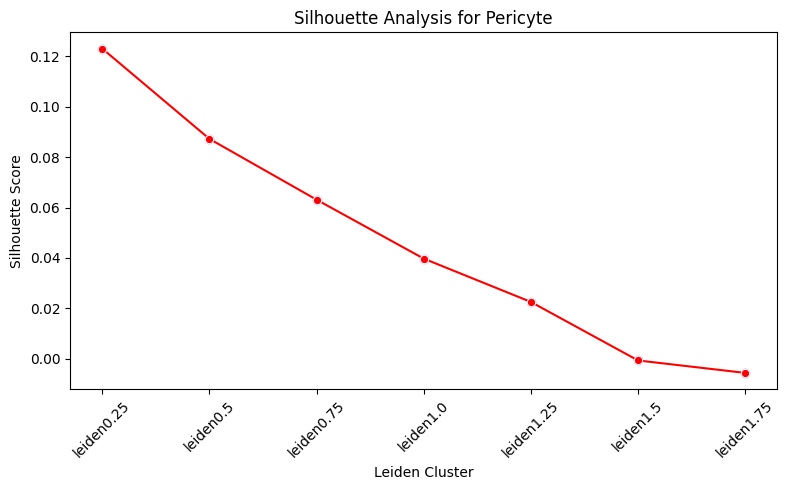

In [5]:
funcs.silhouette(adata, silhouette_res_dir = "../silhouette_res_scVI/", cell_type = cell_type)

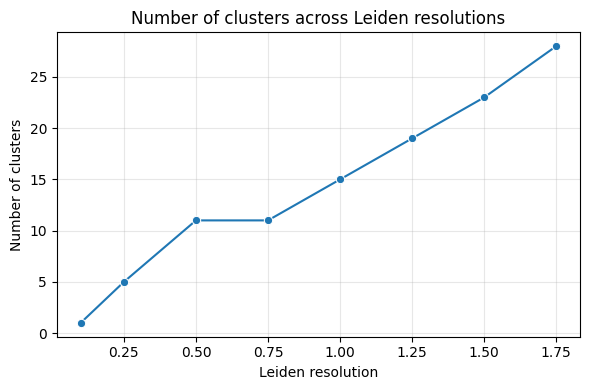

In [6]:
cluster_df, fig = funcs.leiden_resolution_summary(adata)

### Use Leiden 0.5

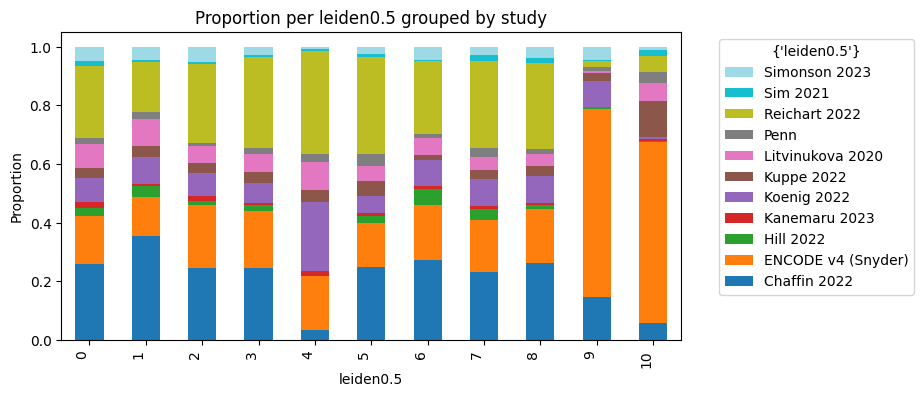

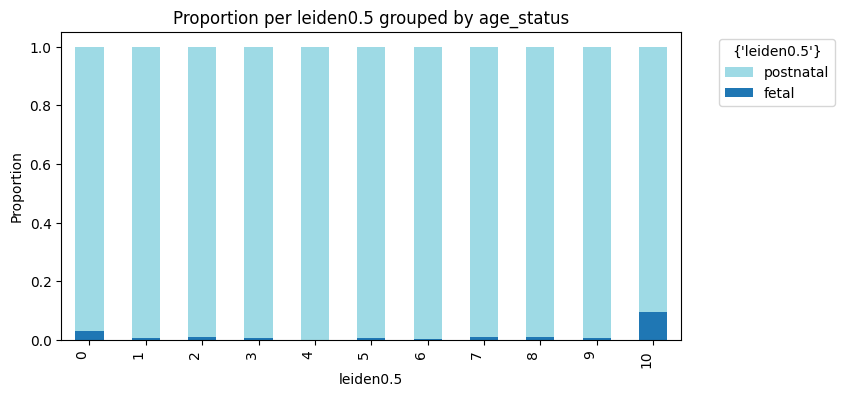

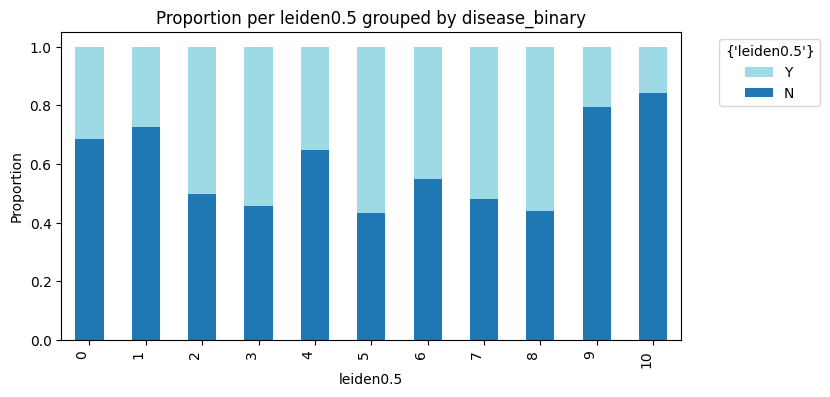

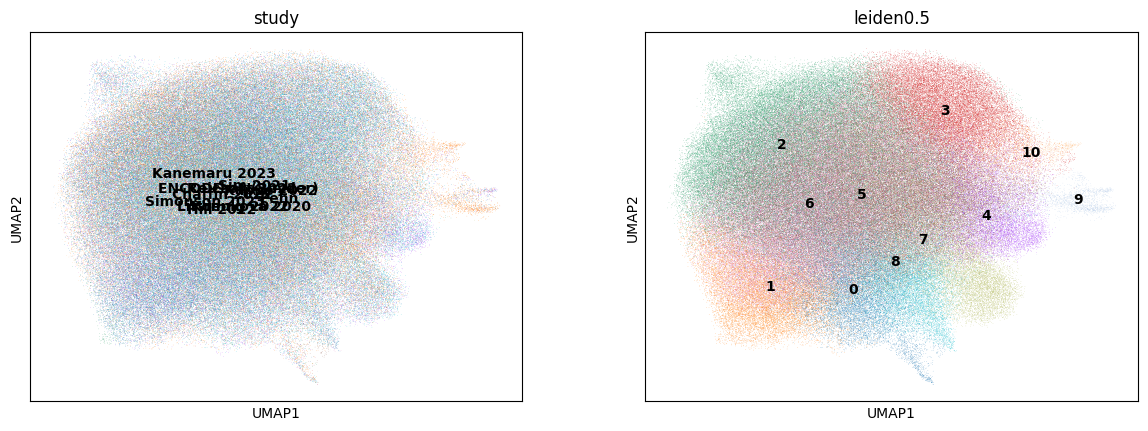

/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 16115 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


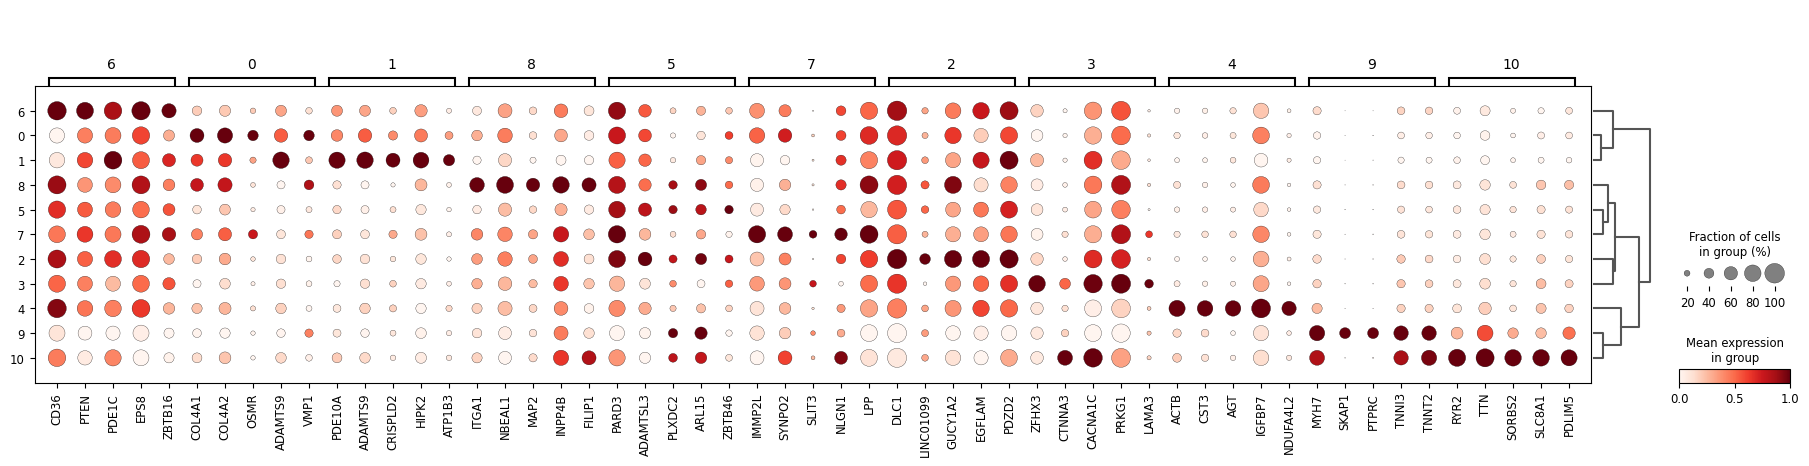

Counter({'5': 75524, '2': 50512, '6': 45054, '3': 26592, '7': 19319, '1': 18588, '8': 17961, '0': 15029, '4': 10352, '9': 1647, '10': 1206})
CPU times: user 19min 43s, sys: 1h 22min 32s, total: 1h 42min 16s
Wall time: 2min 8s


['leiden0.5',
 AnnData object with n_obs × n_vars = 281784 × 16115
     obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type', 'final_cell_type', 'total_UMI', 'log10_UMI', 'endo_score', 'cm_score', 'fib_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'l

In [7]:
%%time
leiden_key = "leiden0.5"
funcs.specify_leiden_subclustering(adata=adata, leiden=leiden_key)

In [8]:
adata.obs['age_disease'] = adata.obs['age_status'].astype(str) + ":" + adata.obs['disease'].astype(str)

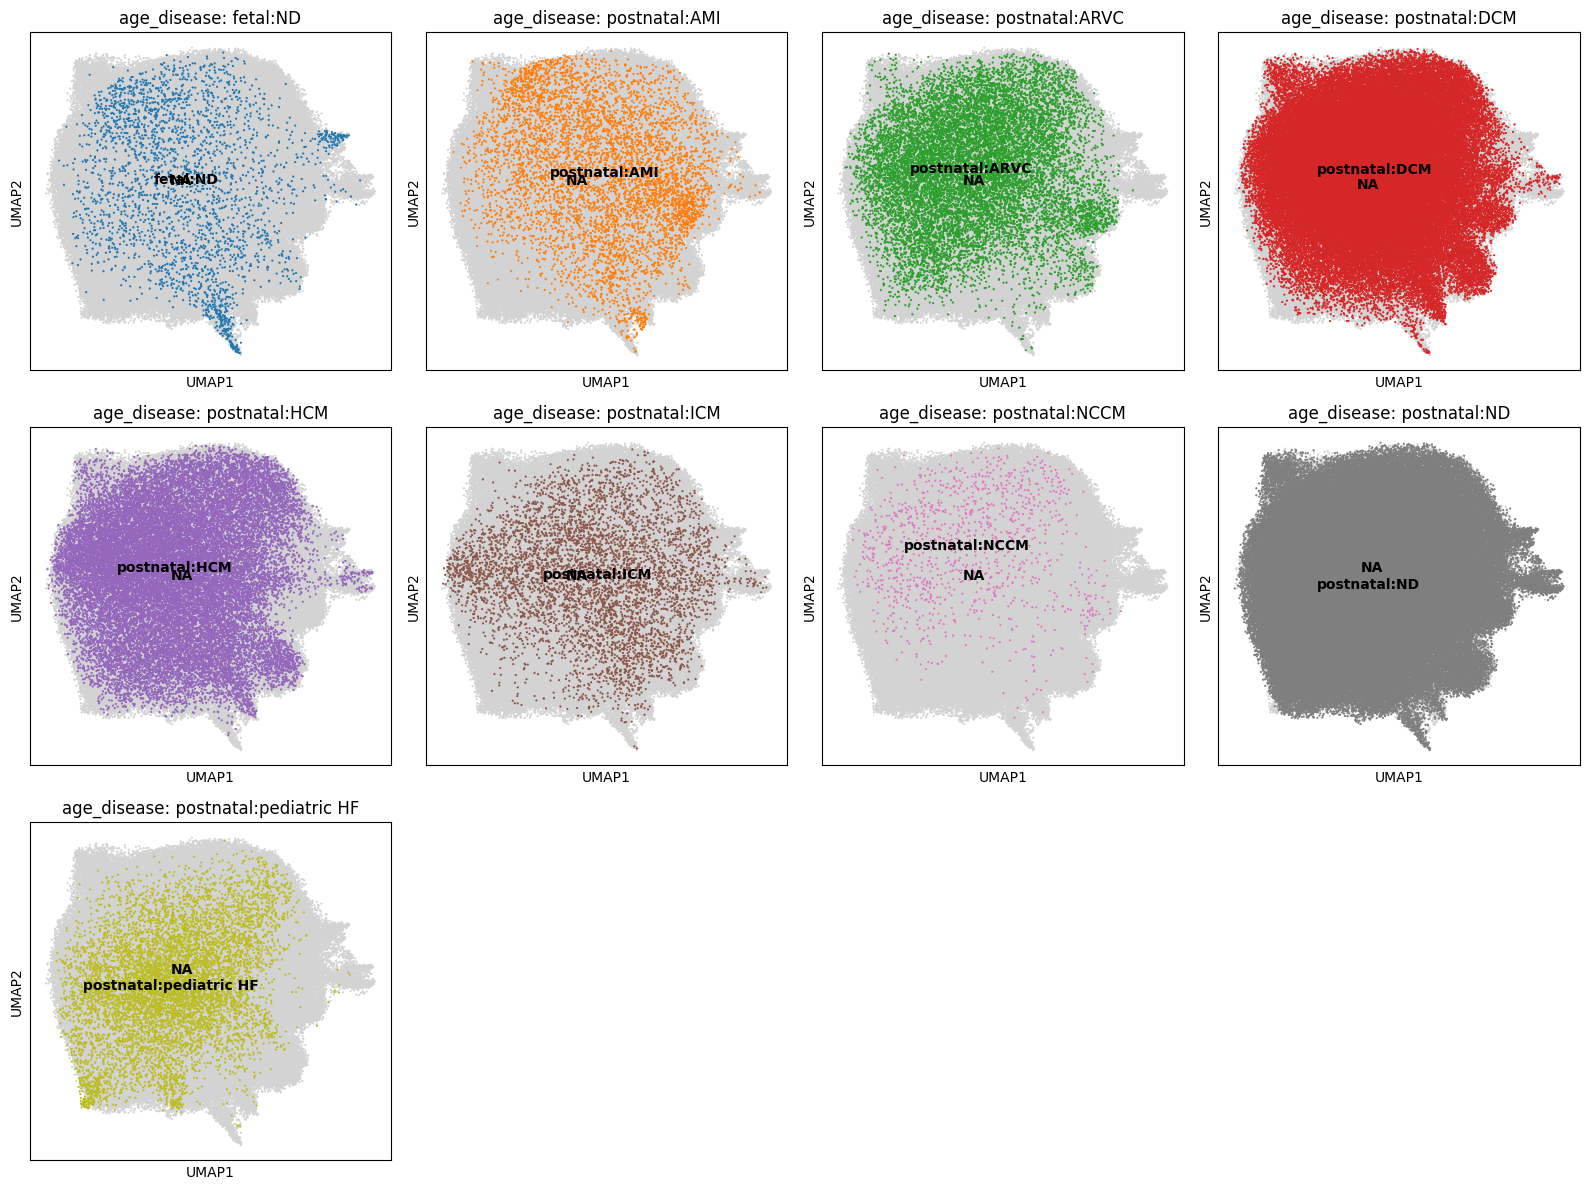

In [9]:
funcs.plot_umap_by_cluster(adata, metadata_key = "age_disease")

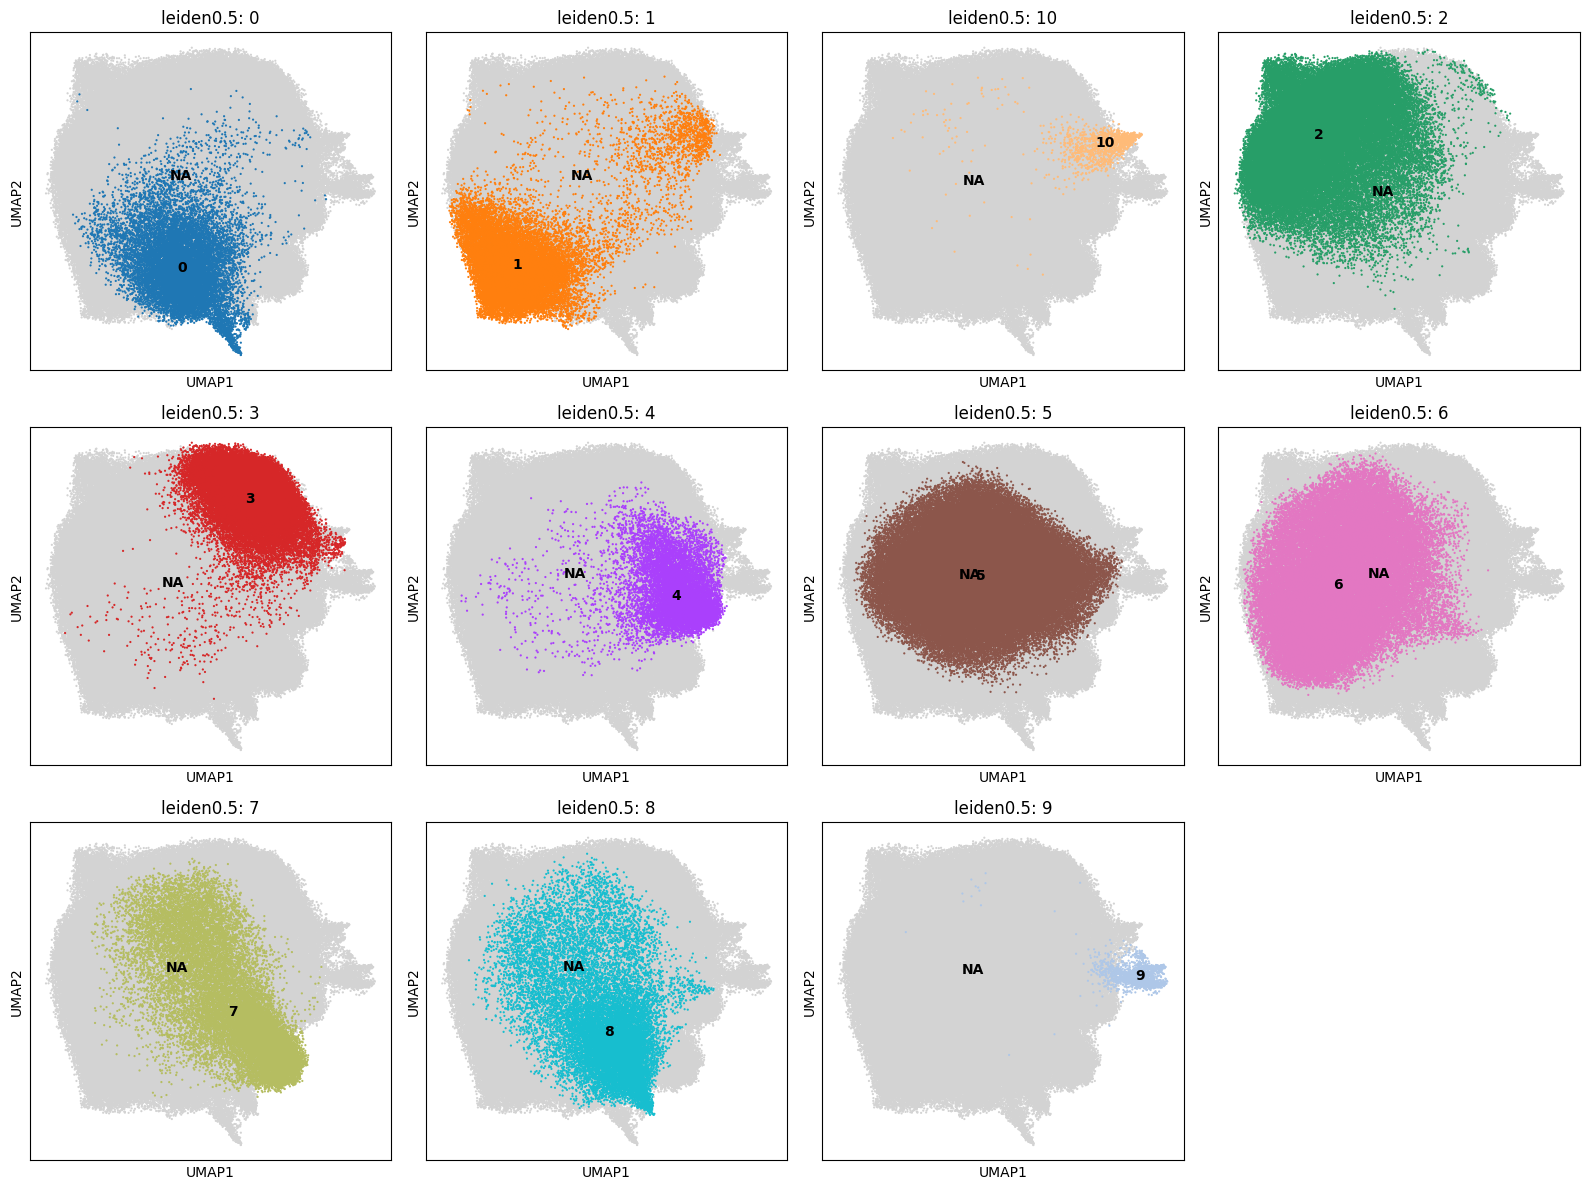

In [10]:
funcs.plot_umap_by_cluster(adata, metadata_key = leiden_key)

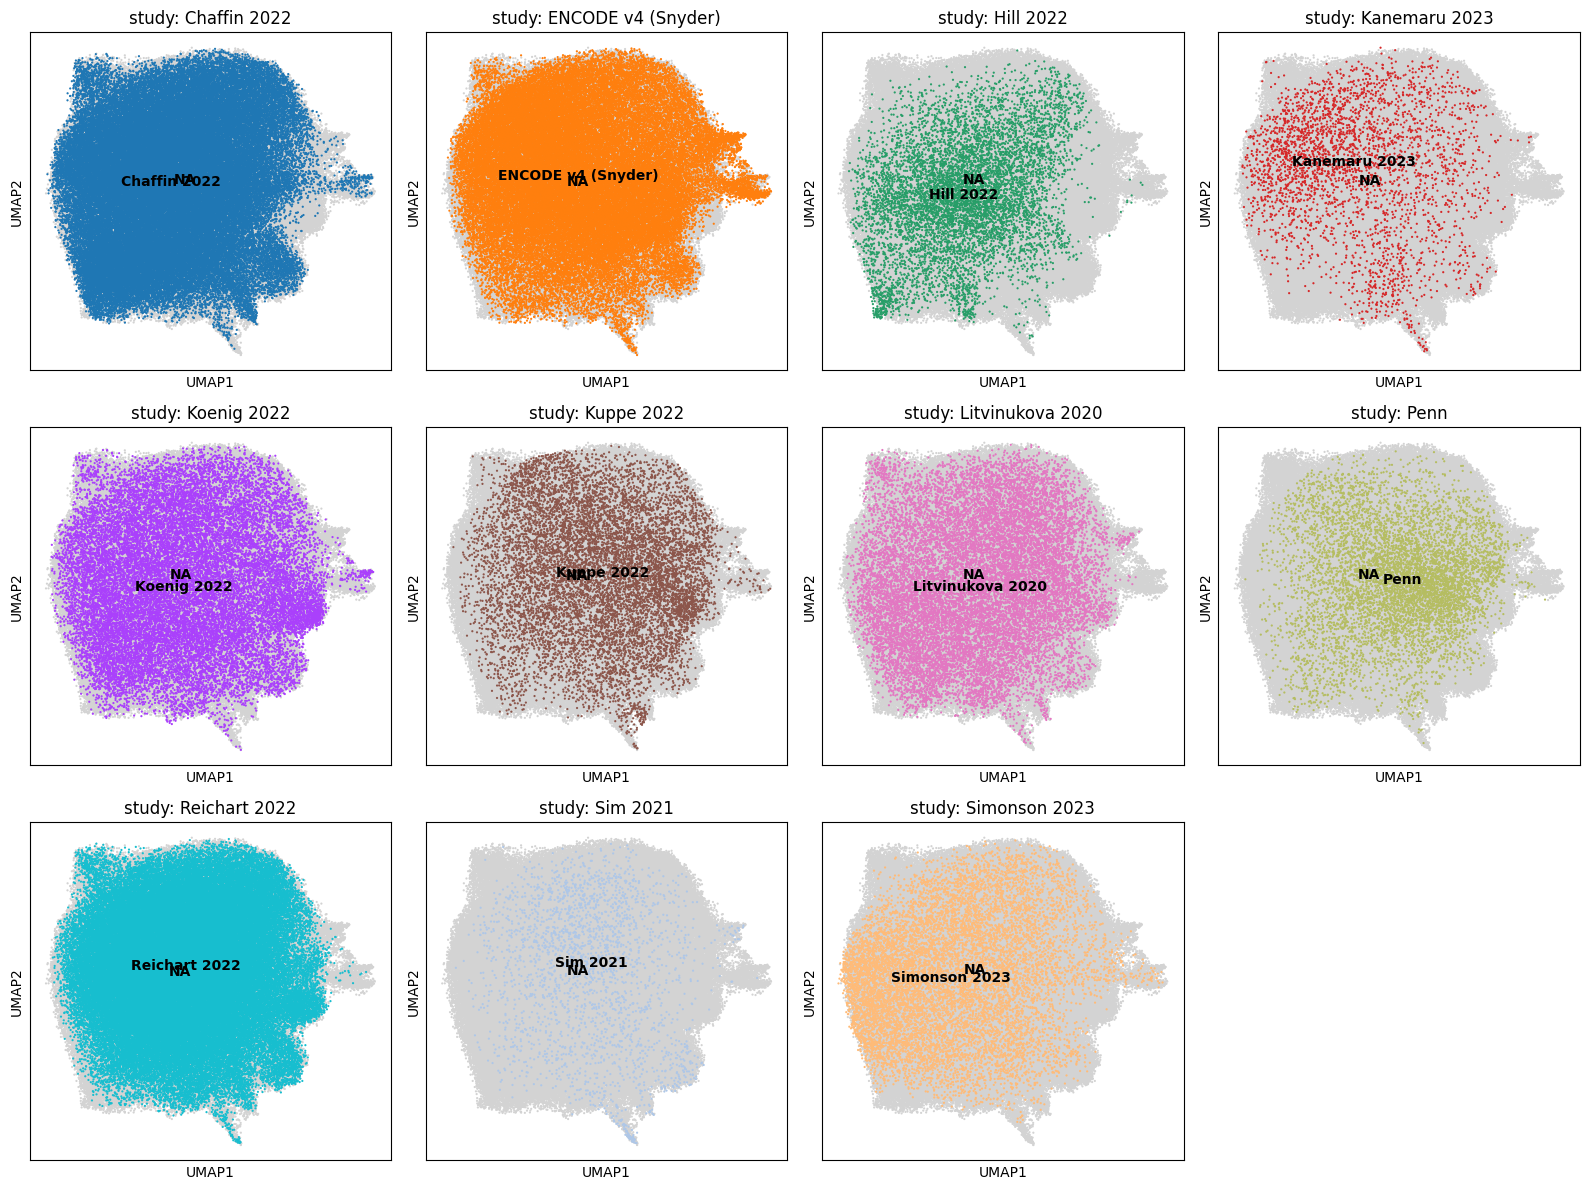

In [11]:
funcs.plot_umap_by_cluster(adata, metadata_key = "study")

In [12]:
#Counter(adata.obs[leiden_key])

### Examine enrichment along metadata categories

/mnt/data1/william/human_heart_project/Final_manuscript_analysis/RNA/aggregated_analysis/v4_subclustering_analysis/examine_covariates/perform_annotation/subcluster_funcs.py:346: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, sub in metadata.groupby(cluster_label):


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>


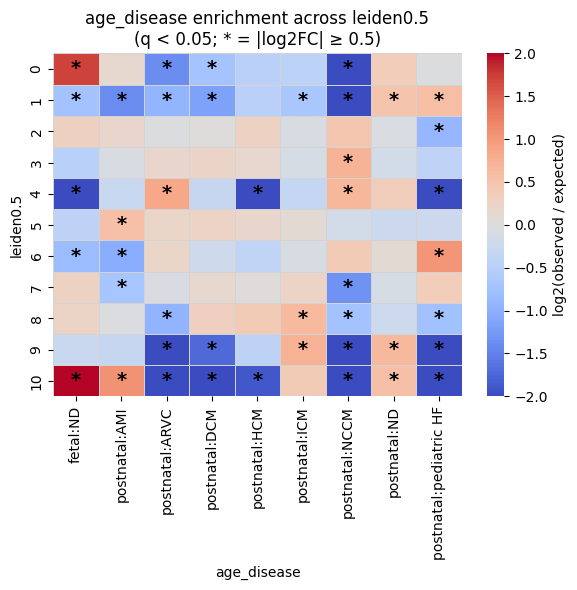

In [13]:
test_df, enrich_df, plot = funcs.chi_square_per_subcluster(
    metadata=adata.obs,
    cluster_label=leiden_key,
    study_col="age_disease",
    min_cells=50, figsize_tuple = (6,6)
)

### Marker gene / ORA analysis

In [28]:
#Counter(adata.obs[leiden_key])

In [34]:
#sc.get.rank_genes_groups_df(adata, group="1").head(50)['names']

Processing Cluster 0... Success.
Processing Cluster 1... Success.
Processing Cluster 2... Success.
Processing Cluster 3... Success.
Processing Cluster 4... Success.
Processing Cluster 5... Success.
Processing Cluster 6... Success.
Processing Cluster 7... Success.
Processing Cluster 8... Success.
Processing Cluster 9... Success.
Processing Cluster 10... Success.


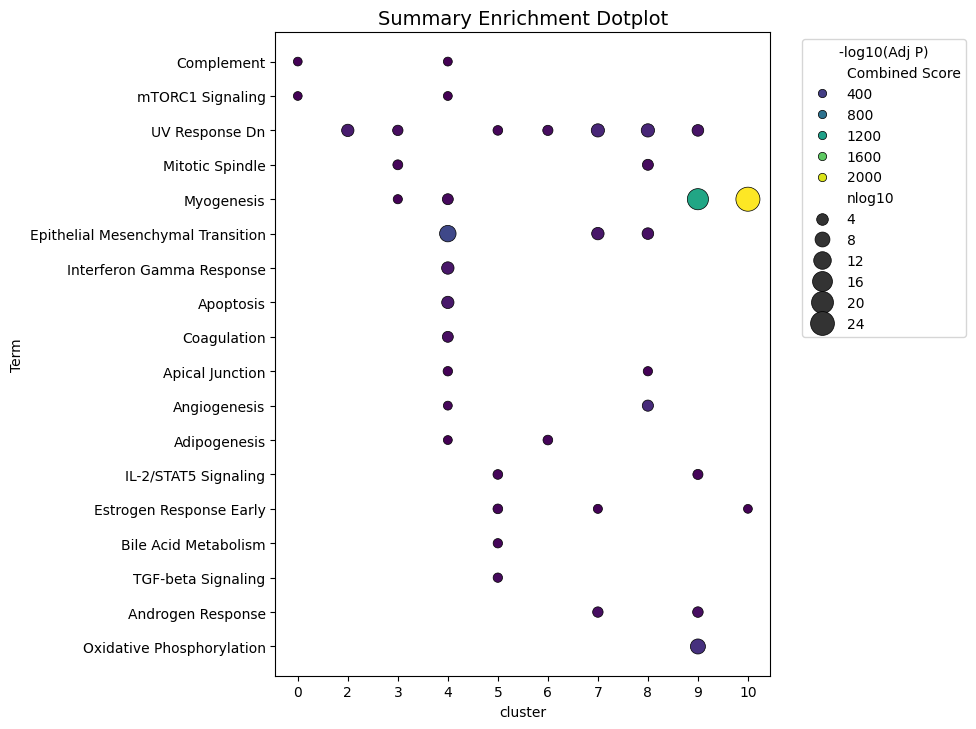

In [15]:
funcs.plot_all_cluster_enrichment(
     adata, cluster_key=leiden_key, 
     gene_sets=["MSigDB_Hallmark_2020"], outdir=None,top_n=100)

- Cluster 0: fetal-enriched; show enrichment for basement membrane (COL4A1/COL4A2/RUNX1)
- Cluster 1 is remodeling pericytes, like in proteases (ADAMTS1/ADAMTS4/ADAMTS9/PDE10A/HEYL/ACE2)
- Cluster 2/3 are regulatory (PRKG1/CACNA1C/CACNB2)
- Cluster 4 are metabolic (RGS5/FABP4/SPARCL1/IGFBP7)
- Cluster 5: major cluster in middle - call "other"
- Cluster 6: major cluster in middle - call "other"
- Cluster 7: activated/mesenchymal/remodeling (PRRX1/SMOC2/ZEB2/TIMP3) -- enriched in fetal and disease states
- Cluster 8 are also structural/basement-mebrane-interacting: COL4A1/COL4A2/TFPI
- Cluster 9 is a small cluster - call "other"
- Cluster 10 is a small cluster - call "other"

In [1]:
#sc.get.rank_genes_groups_df(adata, group="3").head(50)['names']

In [52]:
adata.obs['subcluster'] = adata.obs[leiden_key].map(
    {"0": "Fetal-enriched",
     "1": "Remodeling",
     "2": "Regulatory",
     "3": "Regulatory",
     "4": "Metabolic",
      "5": "Other",
      "6": "Other",
      "7": "Fibroblast-like",
      "8": "Contractile",
      "9": "Other",
      "10": "Other"
    }
)

subcluster_order = [
    "Contractile",
    "Fibroblast-like",
    "Fetal-enriched",
    "Metabolic", 
    "Regulatory",
    "Remodeling",
    "Other"
]

adata.obs['subcluster'] = pd.Categorical(
    adata.obs['subcluster'], categories=subcluster_order, ordered=True
)

subcluster_colors = {
    "Contractile": "cyan",
    "Fibroblast-like": "orange",
    "Metabolic": "red",
    "Regulatory": "purple",
    "Remodeling": "blue",
    "Fetal-enriched": "pink",
    "Other": "gray",
    "Activated": "yellow"
}

adata.uns['subcluster_colors'] = [subcluster_colors[sc] for sc in subcluster_order]

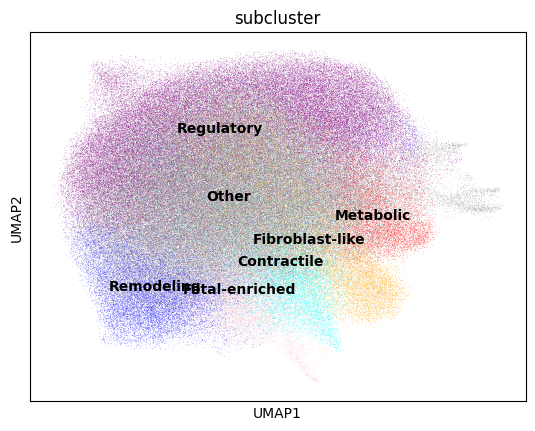

In [53]:
with plt.rc_context(): 
    sc.pl.umap(adata, color = ['subcluster'], legend_loc = "on data", palette = subcluster_colors, show=False)
    plt.savefig(plots_dir + cell_type + "_subclustered.pdf", bbox_inches="tight")

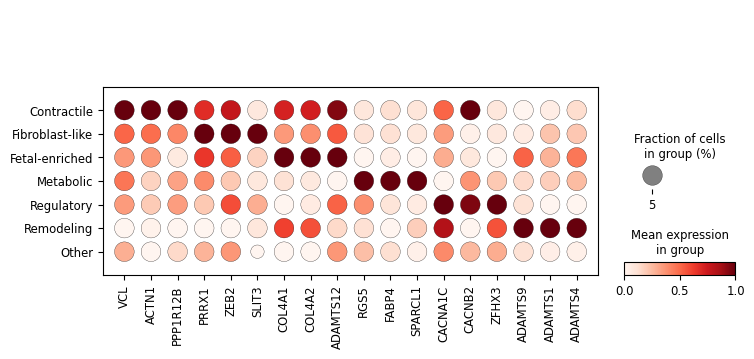

In [63]:
with plt.rc_context(): 
    sc.pl.dotplot(adata, var_names = ["VCL", "ACTN1", "PPP1R12B",
                                       "PRRX1", "ZEB2", "SLIT3",
                                       "COL4A1", "COL4A2", "ADAMTS12",
                                     "RGS5", "FABP4", "SPARCL1",
                                      "CACNA1C", "CACNB2", "ZFHX3",
                                     "ADAMTS9", "ADAMTS1", "ADAMTS4",], groupby = "subcluster", standard_scale='var', 
                  show=False, dot_max=0.05)
    plt.savefig(plots_dir + cell_type + "_subclustered_dotplot.pdf", bbox_inches="tight")

### Show enrichments by disease-age status and age group

In [65]:
adata_metadata = adata.obs

disease_filtered_metadata = adata_metadata[~adata_metadata['age_disease'].isin(["postnatal:ARVC", "postnatal:NCCM"])].copy()
for col in disease_filtered_metadata.select_dtypes('category').columns:
    disease_filtered_metadata[col] = disease_filtered_metadata[col].cat.remove_unused_categories()
    
ND_adata_metadata = adata_metadata[adata_metadata['disease_binary'] == "N"].copy()

/mnt/data1/william/human_heart_project/Final_manuscript_analysis/RNA/aggregated_analysis/v4_subclustering_analysis/examine_covariates/perform_annotation/subcluster_funcs.py:346: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, sub in metadata.groupby(cluster_label):


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>


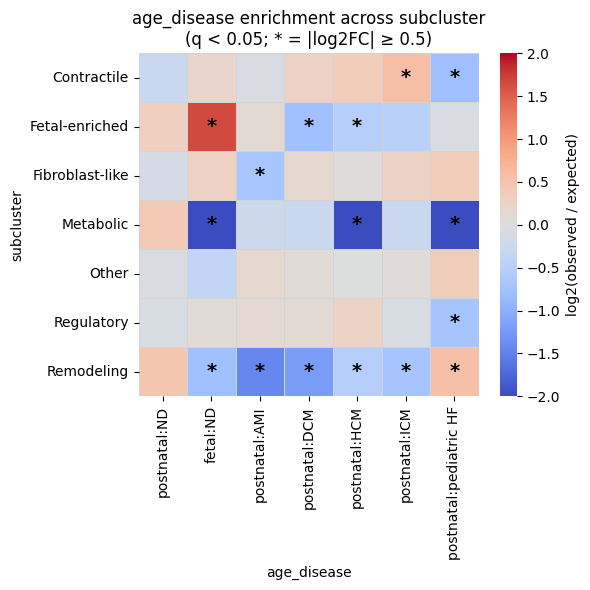

In [66]:
test_df, enrich_df, plot = funcs.chi_square_per_subcluster(
    metadata=disease_filtered_metadata,
    cluster_label="subcluster",
    study_col="age_disease",
    metadata_order = ['postnatal:ND', 'fetal:ND', 'postnatal:AMI', 'postnatal:DCM', 
                      'postnatal:HCM', 'postnatal:ICM', 'postnatal:pediatric HF'],
    min_cells=50, figsize_tuple = (6,6)
)

plot.savefig(plots_dir + cell_type + "_subcluster_age_disease.pdf")

/mnt/data1/william/human_heart_project/Final_manuscript_analysis/RNA/aggregated_analysis/v4_subclustering_analysis/examine_covariates/perform_annotation/subcluster_funcs.py:346: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, sub in metadata.groupby(cluster_label):


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>


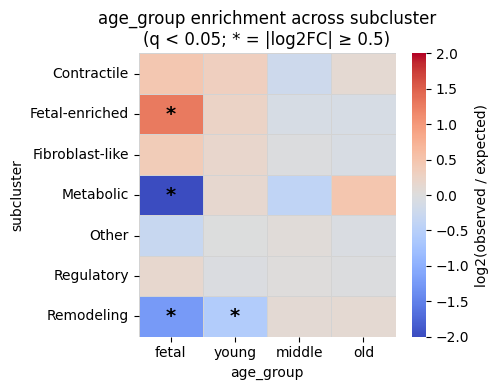

In [69]:
test_df, enrich_df, plot = funcs.chi_square_per_subcluster(
    metadata=ND_adata_metadata,
    cluster_label="subcluster",
    metadata_order = ["fetal", "young", "middle", "old"],
    study_col="age_group",
    min_cells=50, figsize_tuple = (5,4)
)

plot.savefig(plots_dir + cell_type + "_subcluster_aging.pdf")

In [70]:
subcluster_stats = (
    adata.obs['subcluster']
    .value_counts(normalize=False)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "subcluster"})
)

subcluster_stats["proportion"] = subcluster_stats["count"] / subcluster_stats["count"].sum()

print(subcluster_stats)

        subcluster   count  proportion
0            Other  123431    0.438034
1       Regulatory   77104    0.273628
2  Fibroblast-like   19319    0.068560
3       Remodeling   18588    0.065965
4      Contractile   17961    0.063740
5   Fetal-enriched   15029    0.053335
6        Metabolic   10352    0.036737


### Save metadata

In [71]:
adata.obs.to_csv(post_subclustering_dir + cell_type + "_annotation.csv")